# 08 · Correlating sound with pH

Build acoustic time series (the level in **any narrow band you choose**, excess over a background, or the
trigger rate of all or only loud events), and pH or **dpH/dt**. Then correlate them honestly:

* **n_eff**: two smooth series correlate whatever the mechanism. The effective number of independent pairs
  (Bretherton et al. 1999) sets the p-value, not n.
* **differences=True**: correlate changes against changes, which removes a shared trend.
* **band scan**: which frequency band tracks pH? Look for a coherent range of bands, not a single one.

On the demo (a single decaying reaction) every band correlates at |r| ≈ 0.9 with n_eff ≈ 2, which is
**not significant**. That is the correct answer: one monotonic run cannot establish a relation. Several takes
under different conditions can.

In [1]:
# ==== YOUR SETTINGS ====
CONFIG = "../config/demo.yaml"
CH = 1
BAND_HZ = (3000.0, 6000.0)        # any band, chosen after processing (from the stored spectrogram)
BASELINE_TAKE, BASELINE = "DEMO_002", (5.0, 34.0)
START_AFTER = "2026-10-01 10:03:00"   # use pH after the reaction started
DT_S = 10.0
MAX_LAG_S = 120.0
LOUD_EVENT_DB = -55.0             # "loud" triggers only (envelope dB re FS^2); None = all

In [2]:
# ---- standard setup (same in every notebook) ----
%matplotlib inline
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import zoom_acoustics as za
from zoom_acoustics import plots as zp, dsp

cfg = za.load_config(CONFIG)
print("config   :", cfg.config_file)
print("data_dir :", cfg.data_dir)
print("cache_dir:", cfg.cache_dir)
print("figures  :", cfg.figures_dir)

config   : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/config/demo.yaml
data_dir : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/audio
cache_dir: /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/cache
figures  : /media/tmittal/Disk1/BKG_Data_Drive/zoom_acoustics_toolkit/demo_data/figures


In [3]:
from zoom_acoustics import correlate as R
feats = [f for f in za.load_all_features(cfg) if CH in f.channels]
fb = za.load_features(cfg, BASELINE_TAKE)
ph = za.ph.load_ph_from_config(cfg)
ph = ph[ph.index > pd.Timestamp(START_AFTER)]
dph = R.ph_rate(ph, smooth_s=90)
band = R.band_timeline(feats, CH, *BAND_HZ, dt=DT_S)
b0 = R.band_level_from_psd(fb, CH, *BAND_HZ)
base = float(b0[(b0.index >= BASELINE[0]) & (b0.index < BASELINE[1])].mean())
band_ex = R.excess(band, base)
rate_all = R.event_count_timeline(feats, CH, bin_s=DT_S)
rate_loud = R.event_count_timeline(feats, CH, bin_s=DT_S, min_env_db=LOUD_EVENT_DB)
print(f"baseline in {BAND_HZ} Hz: {10*np.log10(base):.1f} dB re FS^2")

baseline in (3000.0, 6000.0) Hz: -73.3 dB re FS^2


## Level in the chosen band vs pH, and vs dpH/dt

,value
lag_s,30.0
pearson_r,-0.962679
spearman_rho,-0.95177
slope_y_per_dB,-0.086335
n,27
n_eff,2
lag1_autocorr_x,0.940113
lag1_autocorr_y,0.992291
p_value_neff,0.174476


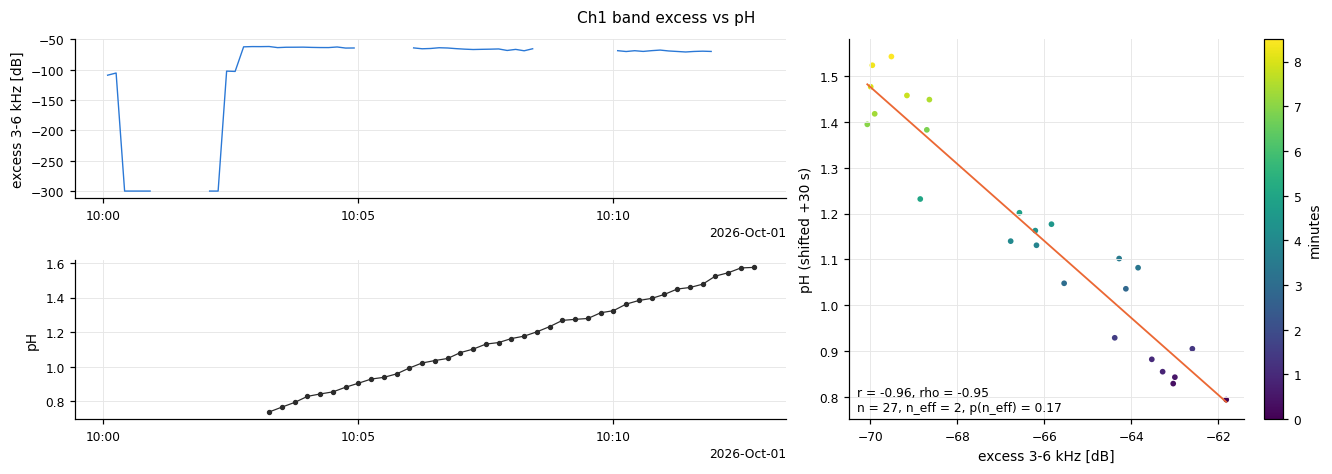

In [4]:
res, scan = R.correlate(band_ex, ph["pH"], dt_s=DT_S, max_lag_s=MAX_LAG_S)
fig = zp.plot_correlation_panel(band_ex, ph["pH"], res, x_label=f"excess {BAND_HZ[0]/1e3:g}-{BAND_HZ[1]/1e3:g} kHz [dB]",
                                title=f"Ch{CH} band excess vs pH")
zp.save(fig, cfg, "corr_band_vs_pH")
pd.Series(res).drop("note", errors="ignore").to_frame("value")

In [5]:
res_d, _ = R.correlate(band_ex, dph, dt_s=DT_S, max_lag_s=MAX_LAG_S)
res_diff, _ = R.correlate(band_ex, ph["pH"], dt_s=DT_S, differences=True)
pd.DataFrame({"vs pH": res, "vs dpH/dt": res_d, "changes vs changes": res_diff}).T[
    ["lag_s", "pearson_r", "spearman_rho", "slope_y_per_dB", "n", "n_eff", "p_value_neff", "note"]]

,lag_s,pearson_r,spearman_rho,slope_y_per_dB,n,n_eff,p_value_neff,note
vs pH,30.0,-0.962679,-0.95177,-0.086335,27,2,0.174476,n_eff < 10: not significant whatever r is
vs dpH/dt,70.0,-0.633762,-0.471429,-0.000146,29,9,0.066844,n_eff < 10: not significant whatever r is
changes vs changes,0.0,-0.460497,-0.523733,-0.004139,12,10,0.180469,


## Trigger rate (all, and loud events only) vs pH

,pearson_r,spearman_rho,n,n_eff,p_value_neff,note
all triggers,-0.983506,-0.976154,25,2,0.115785,n_eff < 10: not significant whatever r is
triggers > -55.0 dB,-0.984505,-0.98442,25,2,0.112215,n_eff < 10: not significant whatever r is


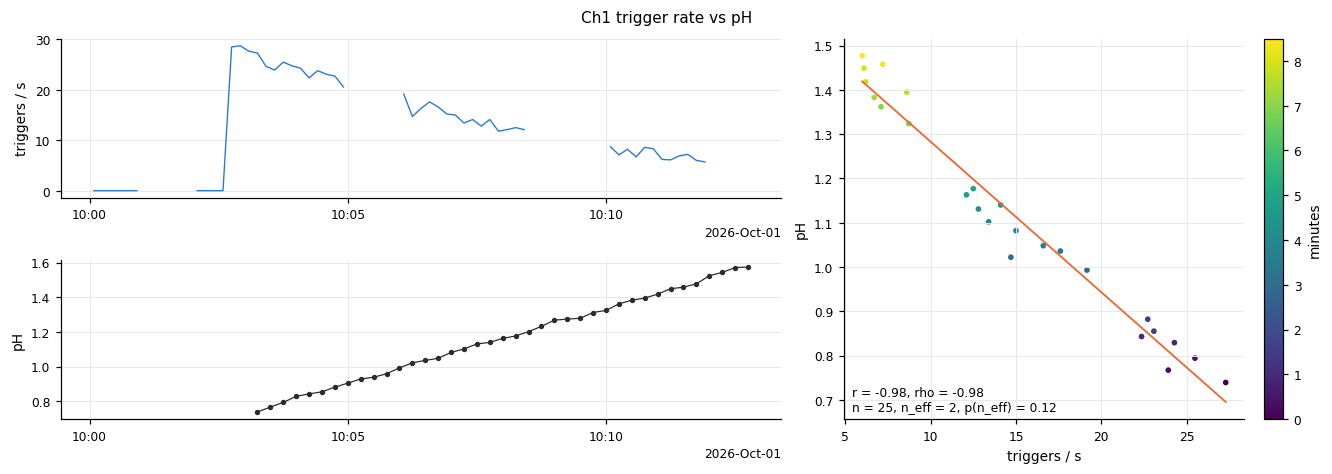

In [6]:
rows = {}
for name, s in (("all triggers", rate_all), (f"triggers > {LOUD_EVENT_DB} dB", rate_loud)):
    r, _ = R.correlate(s, ph["pH"], dt_s=DT_S, x_in_db=False)
    rows[name] = r
fig = zp.plot_correlation_panel(rate_all, ph["pH"], rows["all triggers"], x_label="triggers / s",
                                x_in_db=False, title=f"Ch{CH} trigger rate vs pH")
pd.DataFrame(rows).T[["pearson_r", "spearman_rho", "n", "n_eff", "p_value_neff", "note"]]

## Which band tracks pH? (third-octave scan, excess over the baseline)

Filled markers: p(n_eff) < 0.05. With 16 bands, about 1 passes by chance. The lower panel is the best lag
per band: if it jumps around, the lag is noise.

,f_lo,f_hi,lag_s,pearson_r,slope_y_per_dB,n,n_eff,p_value_neff
0,500.000,629.961,30.0,-0.965,-0.082,27,2,0.168
1,629.961,793.701,30.0,-0.960,-0.082,27,2,0.181
2,793.701,1000.000,-20.0,-0.936,-0.076,24,2,0.229
3,1000.000,1259.921,-20.0,-0.893,-0.069,24,2,0.298
4,1259.921,1587.401,-20.0,-0.900,-0.061,24,2,0.287
5,1587.401,2000.000,-100.0,0.673,0.042,19,3,0.530
6,2000.000,2519.842,30.0,-0.733,-0.051,27,4,0.267
7,2519.842,3174.802,30.0,-0.903,-0.071,27,3,0.283
8,3174.802,4000.000,30.0,-0.913,-0.080,27,2,0.268
9,4000.000,5039.684,30.0,-0.931,-0.082,27,2,0.238


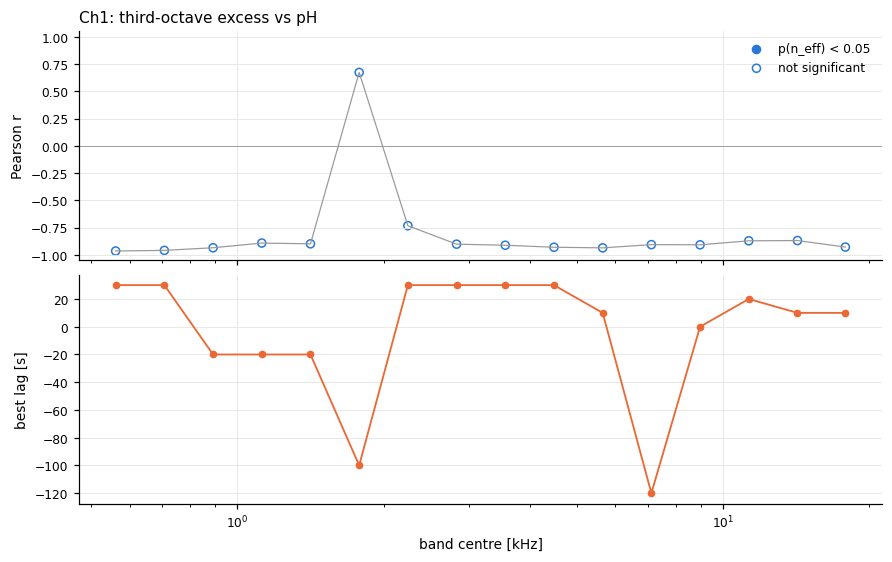

In [7]:
scan = R.band_scan(feats, CH, ph["pH"], bands=R.log_bands(500, 20000, 3), dt_s=DT_S,
                   max_lag_s=MAX_LAG_S, baseline=(fb, BASELINE))
fig = zp.plot_band_scan(scan, f"Ch{CH}: third-octave excess vs pH")
zp.save(fig, cfg, "corr_band_scan")
scan[["f_lo", "f_hi", "lag_s", "pearson_r", "slope_y_per_dB", "n", "n_eff", "p_value_neff"]].round(3)

In [8]:
out = pd.DataFrame({"pH": ph["pH"], "dpH_dt_per_min": dph})
out[f"ch{CH}_{BAND_HZ[0]:g}_{BAND_HZ[1]:g}Hz_excess_dB"] = 10 * np.log10(
    za.ph.acoustic_at(ph.index, band_ex, DT_S, how="mean").to_numpy())
out.to_csv(cfg.figures_path / "ph_band_aligned.csv")
out.dropna().head()

,pH,dpH_dt_per_min,ch1_3000_6000Hz_excess_dB
time,,,
2026-10-01 10:03:15,0.739,0.118800,-61.818318
2026-10-01 10:03:30,0.767,0.108000,-63.639439
2026-10-01 10:03:45,0.794,0.096343,-62.999212
2026-10-01 10:04:00,0.829,0.093429,-62.875464
2026-10-01 10:04:15,0.843,0.088000,-63.529693
